<a href="https://colab.research.google.com/github/Tolureis/CMPE-403-Fundamentals-of-Image-Processing/blob/main/Opencv_Blur_Filters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenCV Filtering Techniques in Python

This notebook demonstrates the use of different filtering techniques available in OpenCV. We will explore the **box filter**, **custom 2D filter**, **blur (averaging)** and **motion blur**. These filters are often used to smooth images, remove noise, sharpen features or simulate camera motion.

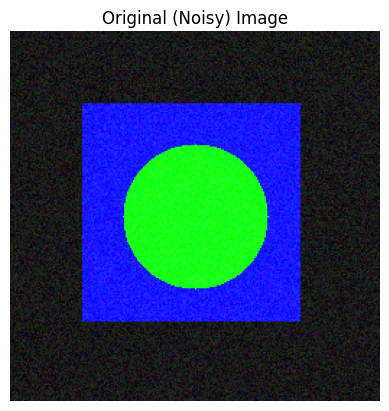

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configure matplotlib for Jupyter
def show_image(title, img):
    # Convert BGR (OpenCV default) to RGB for display
    if len(img.shape) == 3:
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        rgb = img
    plt.imshow(rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Create a synthetic image with simple shapes and noise
def create_sample_image():
    img = np.zeros((256, 256, 3), dtype=np.uint8)
    # blue rectangle
    cv2.rectangle(img, (50, 50), (200, 200), (255, 0, 0), -1)
    # green circle
    cv2.circle(img, (128, 128), 50, (0, 255, 0), -1)
    # random noise
    noise = np.random.randint(0, 50, img.shape, dtype=np.uint8)
    noisy_img = cv2.add(img, noise)
    return noisy_img

# Generate the sample image
sample_img = create_sample_image()
show_image('Original (Noisy) Image', sample_img)

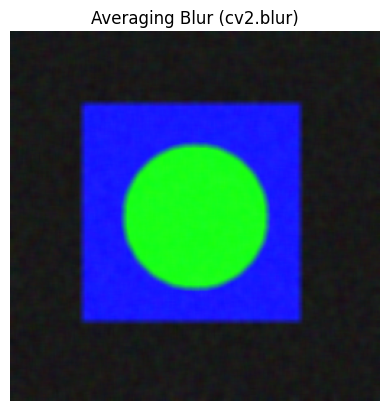

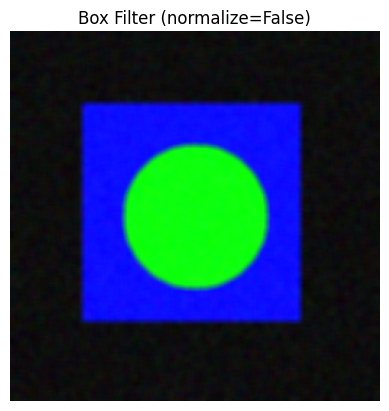

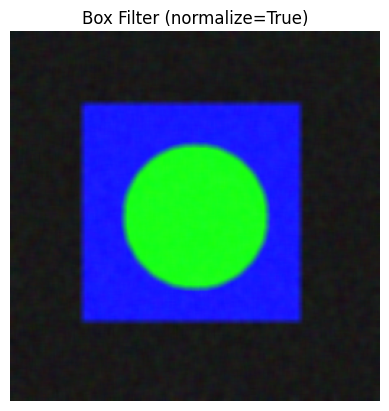

In [ ]:
# Apply a normalized box filter using cv2.blur
blur_5x5 = cv2.blur(sample_img, (5, 5))

# Apply a box filter with normalization disabled (unnormalized)
# We use ddepth=cv2.CV_32F to prevent pixel value overflow during summation
box_unnorm_32f = cv2.boxFilter(sample_img, ddepth=cv2.CV_32F, ksize=(5, 5), normalize=False)
# Normalize the 32-bit float image back to 0-255 (uint8) for proper visualization
box_unnorm = cv2.normalize(box_unnorm_32f, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Apply a box filter with normalization enabled (equivalent to cv2.blur)
box_norm = cv2.boxFilter(sample_img, ddepth=-1, ksize=(5, 5), normalize=True)

# Display results
show_image('Averaging Blur (cv2.blur)', blur_5x5)
show_image('Box Filter (normalize=False)', box_unnorm)
show_image('Box Filter (normalize=True)', box_norm)

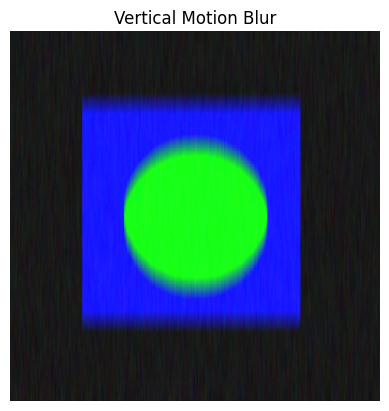

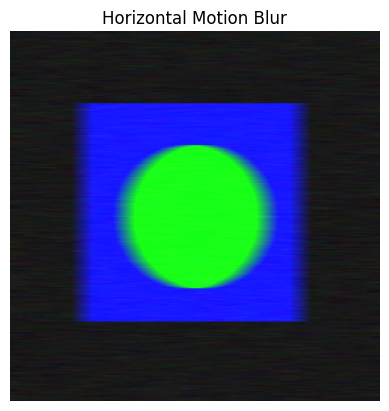

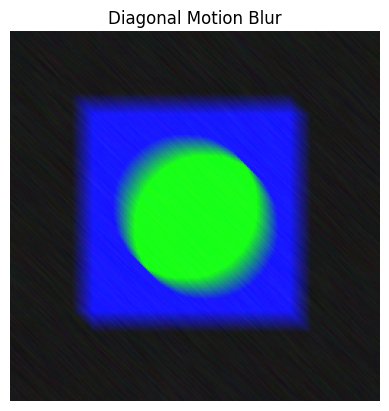

In [ ]:
# Set kernel size for motion blur
kernel_size = 15

# Vertical motion blur kernel
vertical_kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
vertical_kernel[:, kernel_size // 2] = np.ones(kernel_size)
vertical_kernel /= kernel_size

# Horizontal motion blur kernel
horizontal_kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
horizontal_kernel[kernel_size // 2, :] = np.ones(kernel_size)
horizontal_kernel /= kernel_size

# Diagonal motion blur kernel

# Place ones on the main diagonal
# Note: for diagonal, we normalize by kernel_size as well

# Use identity matrix to create diagonal kernel

diagonal_kernel = np.eye(kernel_size, dtype=np.float32)
diagonal_kernel /= kernel_size

# Apply the motion blur kernels
vert_blur = cv2.filter2D(sample_img, -1, vertical_kernel)
horz_blur = cv2.filter2D(sample_img, -1, horizontal_kernel)
diag_blur = cv2.filter2D(sample_img, -1, diagonal_kernel)

# Display results
show_image('Vertical Motion Blur', vert_blur)
show_image('Horizontal Motion Blur', horz_blur)
show_image('Diagonal Motion Blur', diag_blur)